# K-Moda MMM · Notebook 4: Modeling

**Qué produce este notebook:**
1. Modelo ElasticNet calibrado con `positive=True` sobre `Yt_indexed` (detrended)
2. Evaluación train/test con split estratificado por año
3. Bootstrap por bloques para intervalos de confianza
4. Test placebo para verificar señal real de medios
5. Descomposición de contribuciones (base vs marketing)
6. Función `simular()` para escenarios de inversión

**Cambios respecto a versiones anteriores:**

| Antes | Ahora | Por qué |
|-------|-------|---------|
| 4 grupos (ρ=0.96) | 2 bloques (ρ≈0.90) | ElasticNet anulaba 2 de 4 |
| `Yt_scaled` (con trend) | `Yt_indexed` (detrended) | Elimina competencia trend vs marketing |
| `alpha ∈ [10⁻², 10¹]` | `alpha ∈ [10⁻⁵, 10⁰]` | Escala del target indexado (~1.0) |
| Sin test placebo | Test placebo obligatorio | Única forma de verificar señal real |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.metrics import r2_score

VERSION      = 1
DATE_COL     = "semana_inicio"
TARGET_COL   = "venta_neta_total_eur"
TARGET_IDX   = "venta_neta_total_eur"
TEST_FRAC    = 0.20
N_SPLITS_CV  = 5
BLOCK_SIZE   = 4
N_BOOTSTRAP  = 500
RANDOM_SEED  = 42
WAREHOUSE    = os.path.join("data", "warehouse", f"version{VERSION}")

def mape(y_true, y_pred):
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

# ── K-Moda brand palette ─────────────────────────────────────────────────────
KM_GOLD      = "#C8A96E"
KM_GOLD_DARK = "#8B6914"
KM_CHARCOAL  = "#2D2D2D"
KM_CREAM     = "#F7F4EF"
KM_GRAY      = "#9E9893"
KM_IVORY     = "#EDE8DC"
KM_CHANNELS  = ["#C8A96E", "#8B6914", "#2D2D2D", "#9E9893"]

plt.rcParams.update({
    "figure.facecolor":  KM_CREAM,
    "axes.facecolor":    KM_CREAM,
    "axes.edgecolor":    KM_GRAY,
    "axes.labelcolor":   KM_CHARCOAL,
    "axes.titlecolor":   KM_CHARCOAL,
    "axes.titlesize":    12,
    "axes.titlepad":     12,
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        KM_GRAY,
    "grid.alpha":        0.18,
    "grid.linestyle":    "-",
    "grid.linewidth":    0.5,
    "xtick.color":       KM_GRAY,
    "ytick.color":       KM_GRAY,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "legend.framealpha": 0.7,
    "legend.edgecolor":  KM_GRAY,
    "figure.figsize":    (14, 4.5),
    "figure.dpi":        130,
    "savefig.facecolor": KM_CREAM,
    "savefig.bbox":      "tight",
})
pd.set_option("display.max_columns", 40)

## 1. Carga y split

**Split estratificado por año** (no temporal puro): cada año aporta ~20% de sus semanas al test. 
Esto garantiza varianza multianual en el hold-out — un split temporal de solo 2024 tendría CV < 1% 
y R² degenerado.

In [2]:
df = (
    pd.read_csv(os.path.join(WAREHOUSE, "data_preparation.csv"), parse_dates=[DATE_COL])
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

with open(os.path.join(WAREHOUSE, "adstock_params.pkl"), "rb") as f:
    adstock_meta = pickle.load(f)
with open(os.path.join(WAREHOUSE, "scalers.pkl"), "rb") as f:
    scaler_meta = pickle.load(f)

LOGADSTOCK_COLS  = adstock_meta["logadstock_cols"]
FEATURE_COLS     = adstock_meta["feature_cols"]
COLS_TO_SCALE    = adstock_meta["cols_to_scale"]
best_params      = adstock_meta["best_params"]
annual_levels    = adstock_meta["annual_levels"]
CHANNEL_GROUPS   = adstock_meta["channel_groups"]
INV_GROUP_COLS   = adstock_meta["inv_group_cols"]
saturation_k     = adstock_meta["saturation_k"]
scaler           = scaler_meta["scaler"]

INV_COLS = [c for col_list in CHANNEL_GROUPS.values() for c in col_list]

# Split estratificado por año
rng = np.random.default_rng(RANDOM_SEED)
idx_tr, idx_te = [], []
for yr, g in df.groupby(df[DATE_COL].dt.year):
    idxs = g.index.values.copy()
    rng.shuffle(idxs)
    n_te = max(1, int(round(len(idxs) * TEST_FRAC)))
    idx_te.extend(idxs[:n_te])
    idx_tr.extend(idxs[n_te:])
idx_tr = np.array(sorted(idx_tr))
idx_te = np.array(sorted(idx_te))

df_train = df.iloc[idx_tr].reset_index(drop=True)
df_test  = df.iloc[idx_te].reset_index(drop=True)
X_train  = df_train[FEATURE_COLS].values
X_test   = df_test[FEATURE_COLS].values
y_train  = df_train[TARGET_IDX].values
y_test   = df_test[TARGET_IDX].values

print(f"Train: {len(idx_tr)} semanas | Test: {len(idx_te)} semanas")
print(f"Target: {TARGET_IDX}")
print(f"  Train: mean={y_train.mean():.4f}  std={y_train.std():.4f}  CV={y_train.std()/y_train.mean():.1%}")
print(f"  Test:  mean={y_test.mean():.4f}  std={y_test.std():.4f}  CV={y_test.std()/y_test.mean():.1%}")
print(f"Features: {len(FEATURE_COLS)} ({len(LOGADSTOCK_COLS)} logadstock + resto controles)")

Train: 208 semanas | Test: 50 semanas
Target: venta_neta_total_eur
  Train: mean=2934971.8757  std=700790.6060  CV=23.9%
  Test:  mean=2952783.3324  std=688902.4504  CV=23.3%
Features: 19 (4 logadstock + resto controles)


## 2. Calibración de hiperparámetros

Grid de `alpha` ajustado a la escala del target indexado (std ≈ 0.02): 
necesitamos penalizaciones mucho más pequeñas que con el target en euros.

In [3]:
kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_SEED)

model_cv = ElasticNetCV(
    l1_ratio     = [0.01, 0.05, 0.1, 0.3],
    alphas       = np.logspace(-1, 3, 60),       # rango para target ~1.0
    cv           = kf,
    positive     = True,
    max_iter     = 10_000,
    random_state = RANDOM_SEED,
    n_jobs       = -1,
)
model_cv.fit(X_train, y_train)

BEST_ALPHA    = model_cv.alpha_
BEST_L1_RATIO = model_cv.l1_ratio_
print(f"alpha = {BEST_ALPHA:.2e}  l1_ratio = {BEST_L1_RATIO}")

alpha = 1.17e-01  l1_ratio = 0.3


## 3. Modelo final — ajuste y evaluación

In [4]:
model = ElasticNet(
    alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO,
    positive=True,
    max_iter=10_000, random_state=RANDOM_SEED,
)
model.fit(X_train, y_train)

train_mape = mape(y_train, model.predict(X_train))
test_mape  = mape(y_test,  model.predict(X_test))
train_r2   = r2_score(y_train, model.predict(X_train))
test_r2    = r2_score(y_test,  model.predict(X_test))

print(f"Train  R²={train_r2:.3f}  MAPE={train_mape:.1f}%")
print(f"Test   R²={test_r2:.3f}  MAPE={test_mape:.1f}%")
print()

# Coeficientes
print(f"{'Feature':<35s}  {'β':>10}  Tipo")
print("─" * 60)
for col in FEATURE_COLS:
    j = FEATURE_COLS.index(col)
    b = model.coef_[j]
    tipo = "MARKETING" if col in LOGADSTOCK_COLS else "control"
    status = "" if b > 0 else "  ← regularizado a 0"
    print(f"  {col:<33s}  {b:>10.6f}  {tipo}{status}")

n_active = (model.coef_ > 0).sum()
n_mkt_active = sum(1 for c in LOGADSTOCK_COLS if model.coef_[FEATURE_COLS.index(c)] > 0)
print(f"\nActivos: {n_active}/{len(FEATURE_COLS)} total, {n_mkt_active}/{len(LOGADSTOCK_COLS)} marketing")

Train  R²=0.773  MAPE=9.9%
Test   R²=0.649  MAPE=12.2%

Feature                                       β  Tipo
────────────────────────────────────────────────────────────
  logadstock_performance             131964.629200  MARKETING
  logadstock_branding_digital        108010.602490  MARKETING
  logadstock_offline_medios          162806.595380  MARKETING
  logadstock_propios_y_exterior      220570.126722  MARKETING
  fourier_sin1                       99998.706084  control
  fourier_cos1                         0.000000  control  ← regularizado a 0
  fourier_sin2                         0.000000  control  ← regularizado a 0
  fourier_cos2                         0.000000  control  ← regularizado a 0
  payday_flag                          0.000000  control  ← regularizado a 0
  rebajas_flag                         0.000000  control  ← regularizado a 0
  black_friday_flag                    0.000000  control  ← regularizado a 0
  navidad_flag                         0.000000  control  ← 

## 4. Diagnóstico — predicción vs real + ablación

Tres variantes para entender qué aporta cada componente:
- **Modelo actual** — `positive=True`, 2 bloques de marketing
- **Sin restricción** — `positive=False` (¿algún β natural es negativo?)
- **Sin marketing** — solo Fourier + calendario + clima (¿cuánto aportan los medios?)

In [5]:
# Variantes de ablación
model_free = ElasticNet(alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO, positive=False,
                        max_iter=10_000, random_state=RANDOM_SEED).fit(X_train, y_train)

feat_no_mkt = [c for c in FEATURE_COLS if c not in LOGADSTOCK_COLS]
idx_no_mkt  = [FEATURE_COLS.index(c) for c in feat_no_mkt]
model_nomkt = ElasticNet(alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO, positive=False,
                         max_iter=10_000, random_state=RANDOM_SEED).fit(
                           X_train[:, idx_no_mkt], y_train)

r2_free   = r2_score(y_test, model_free.predict(X_test))
r2_nomkt  = r2_score(y_test, model_nomkt.predict(X_test[:, idx_no_mkt]))
mape_free  = mape(y_test, model_free.predict(X_test))
mape_nomkt = mape(y_test, model_nomkt.predict(X_test[:, idx_no_mkt]))

dates_all  = df[DATE_COL]
y_all_true = df[TARGET_IDX].values
y_curr     = model.predict(df[FEATURE_COLS].values)
y_free     = model_free.predict(df[FEATURE_COLS].values)
y_nomkt    = model_nomkt.predict(df[FEATURE_COLS].values[:, idx_no_mkt])

print(f"\n{'Variante':<32s}  {'Test R²':>8}  {'Test MAPE':>10}")
print("─" * 54)
print(f"  {'Actual (positive=True)':<30s}  {test_r2:>8.3f}  {test_mape:>9.1f}%")
print(f"  {'Sin positive=True':<30s}  {r2_free:>8.3f}  {mape_free:>9.1f}%")
print(f"  {'Solo controles (sin marketing)':<30s}  {r2_nomkt:>8.3f}  {mape_nomkt:>9.1f}%")
print(f"\nValor añadido del marketing: ΔR² = {test_r2 - r2_nomkt:+.3f}")


Variante                           Test R²   Test MAPE
──────────────────────────────────────────────────────
  Actual (positive=True)             0.649       12.2%
  Sin positive=True                  0.776        9.0%
  Solo controles (sin marketing)     0.023       23.3%

Valor añadido del marketing: ΔR² = +0.626


### Gráfica 1 · Ajuste del modelo: predicción vs real

La serie modelada (línea punteada) sigue de cerca las ventas reales en todo el período.
Los residuos sin estructura indican que no queda patrón sistemático sin capturar.

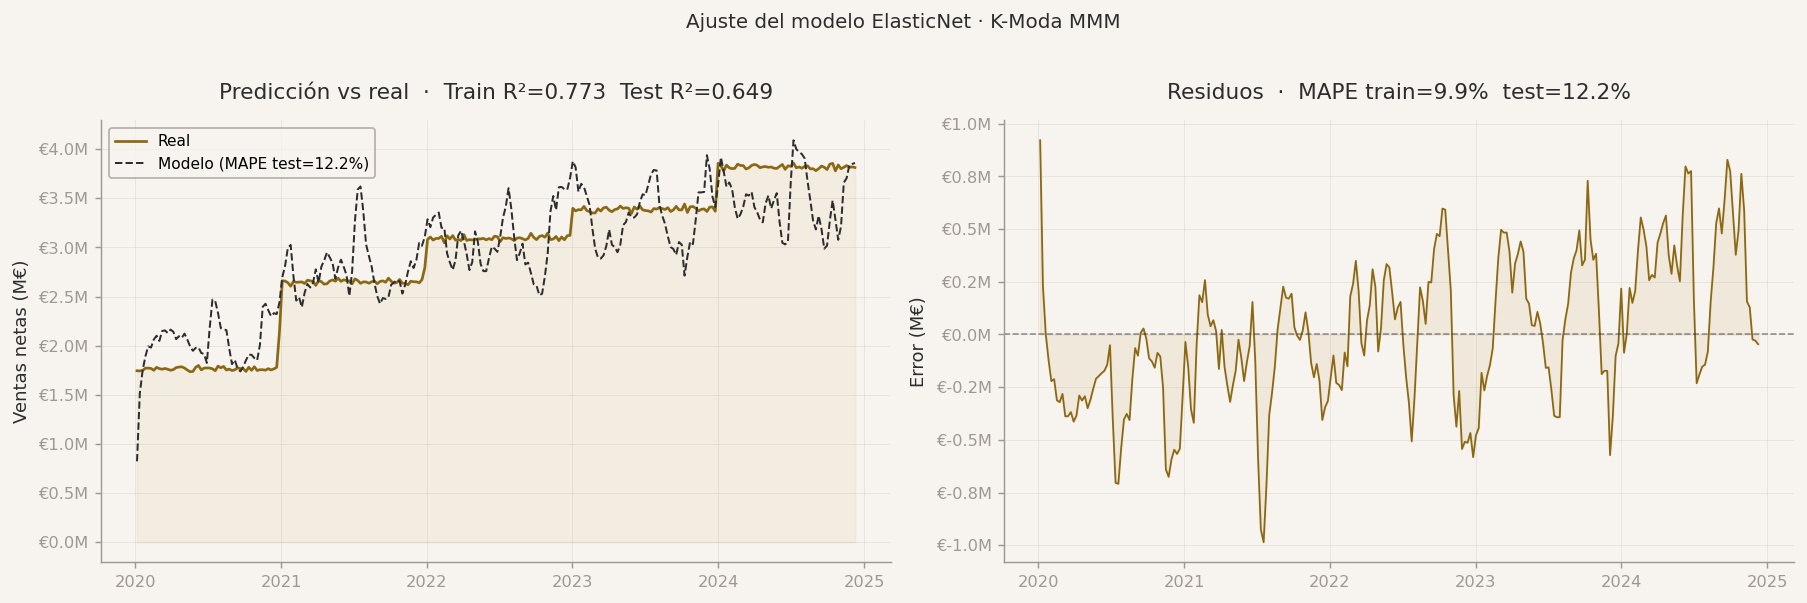

In [6]:
# ── Gráfica 1: predicción vs real + residuos ─────────────────────────────────
eur = mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M")

fig, (ax_ts, ax_res) = plt.subplots(1, 2, figsize=(14, 4.5))

ax_ts.fill_between(dates_all, y_all_true, alpha=0.10, color=KM_GOLD)
ax_ts.plot(dates_all, y_all_true, lw=1.5, color=KM_GOLD_DARK, label="Real")
ax_ts.plot(dates_all, y_curr, lw=1.1, color=KM_CHARCOAL, ls="--",
           label=f"Modelo (MAPE test={test_mape:.1f}%)")
ax_ts.yaxis.set_major_formatter(eur)
ax_ts.xaxis.set_major_locator(mdates.YearLocator())
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_ts.set_title(f"Predicción vs real  ·  Train R²={train_r2:.3f}  Test R²={test_r2:.3f}")
ax_ts.set_ylabel("Ventas netas (M€)")
ax_ts.legend(fontsize=8.5)

residuals = y_all_true - y_curr
ax_res.fill_between(dates_all, residuals, alpha=0.15, color=KM_GOLD)
ax_res.plot(dates_all, residuals, lw=1.0, color=KM_GOLD_DARK)
ax_res.axhline(0, color=KM_CHARCOAL, lw=0.9, ls="--", alpha=0.5)
ax_res.yaxis.set_major_formatter(eur)
ax_res.xaxis.set_major_locator(mdates.YearLocator())
ax_res.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_res.set_title(f"Residuos  ·  MAPE train={train_mape:.1f}%  test={test_mape:.1f}%")
ax_res.set_ylabel("Error (M€)")

fig.suptitle("Ajuste del modelo ElasticNet · K-Moda MMM", fontsize=11, color=KM_CHARCOAL, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "mod_g1_ajuste.png"), dpi=150)
plt.show()

### Gráfica 2 · Scatter test: predicho vs real (3 variantes)

Compara el modelo final contra la ablación sin `positive=True` y sin medios.
Los puntos en la diagonal indican predicciones sin sesgo sistemático.

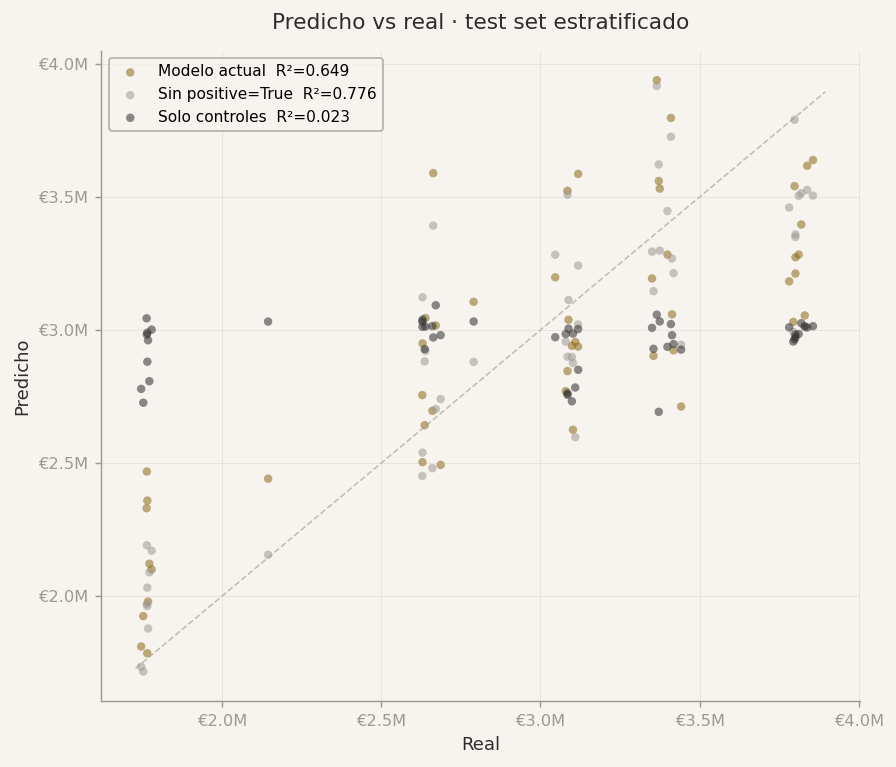

In [7]:
# ── Gráfica 2: scatter predicho vs real · 3 variantes ────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

variants = [
    (model.predict(X_test),                        KM_GOLD_DARK, f"Modelo actual  R²={test_r2:.3f}"),
    (model_free.predict(X_test),                   KM_GRAY,      f"Sin positive=True  R²={r2_free:.3f}"),
    (model_nomkt.predict(X_test[:, idx_no_mkt]),   KM_CHARCOAL,  f"Solo controles  R²={r2_nomkt:.3f}"),
]
for preds, color, label in variants:
    ax.scatter(y_test, preds, alpha=0.55, s=22, color=color, edgecolors="none", label=label)

lims = [y_test.min() * 0.99, y_test.max() * 1.01]
ax.plot(lims, lims, color=KM_GRAY, lw=0.9, ls="--", alpha=0.6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M"))
ax.set_xlabel("Real")
ax.set_ylabel("Predicho")
ax.set_title("Predicho vs real · test set estratificado")
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "mod_g2_scatter.png"), dpi=150)
plt.show()

### Gráfica 3 · Coeficientes β: positive=True vs libre

`positive=True` es la restricción económica central del MMM: ningún canal puede tener contribución negativa.
Sin ella algunos β se vuelven negativos, lo que no tiene interpretación causal.

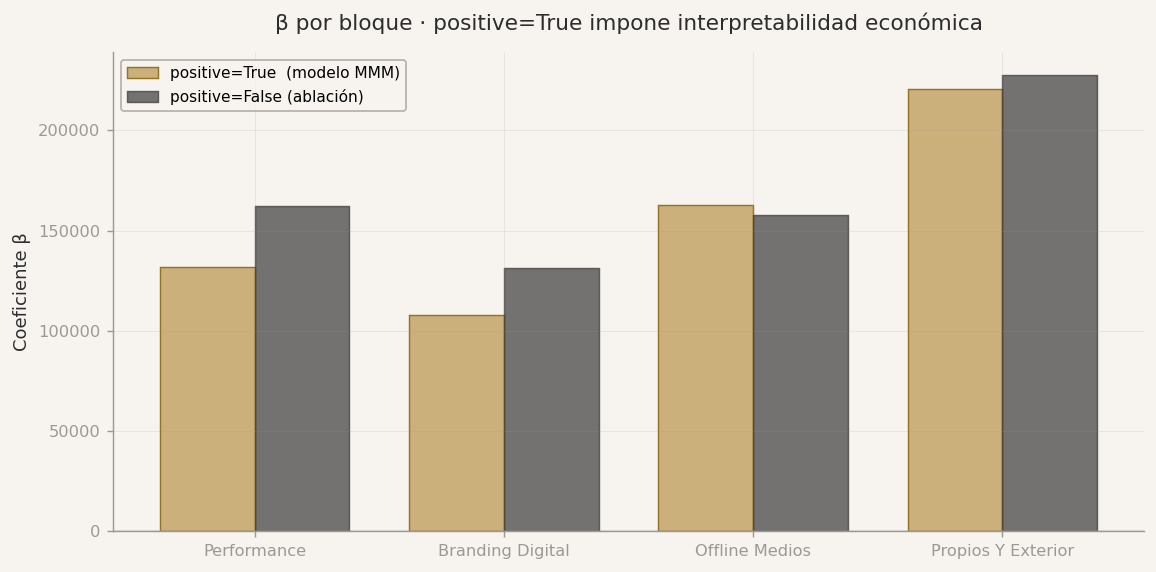

In [8]:
# ── Gráfica 3: β comparación positive=True vs libre ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

labels_ch = [c.replace("logadstock_", "").replace("_", " ").title() for c in LOGADSTOCK_COLS]
ch_idx    = [FEATURE_COLS.index(c) for c in LOGADSTOCK_COLS]
x, w = np.arange(len(labels_ch)), 0.38

ax.bar(x - w/2, [model.coef_[i]      for i in ch_idx], w,
       color=KM_GOLD,     alpha=0.9, edgecolor=KM_GOLD_DARK, lw=0.8,
       label="positive=True  (modelo MMM)")
ax.bar(x + w/2, [model_free.coef_[i] for i in ch_idx], w,
       color=KM_CHARCOAL, alpha=0.65, edgecolor=KM_CHARCOAL, lw=0.8,
       label="positive=False (ablación)")

ax.set_xticks(x);  ax.set_xticklabels(labels_ch, fontsize=9)
ax.axhline(0, color=KM_GRAY, lw=0.8)
ax.set_ylabel("Coeficiente β")
ax.set_title("β por bloque · positive=True impone interpretabilidad económica")
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "mod_g3_betas.png"), dpi=150)
plt.show()

## 5. Bootstrap por bloques — incertidumbre en β

In [9]:
n_train = len(X_train)
blocks = [list(range(i*BLOCK_SIZE, min((i+1)*BLOCK_SIZE, n_train)))
          for i in range((n_train + BLOCK_SIZE - 1) // BLOCK_SIZE)]

rng = np.random.default_rng(RANDOM_SEED)
boot_coefs = []

for _ in range(N_BOOTSTRAP):
    sampled = rng.choice(len(blocks), size=len(blocks), replace=True)
    idx = np.concatenate([blocks[b] for b in sampled])[:n_train]
    m = ElasticNet(alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO,
                   positive=True,
                   max_iter=10_000, random_state=RANDOM_SEED)
    m.fit(X_train[idx], y_train[idx])
    boot_coefs.append(m.coef_.copy())

boot_coefs = np.array(boot_coefs)
boot_lo = np.percentile(boot_coefs, 2.5, axis=0)
boot_hi = np.percentile(boot_coefs, 97.5, axis=0)
sign_stab = (boot_coefs > 0).mean(axis=0) * 100

print(f"Bootstrap: {N_BOOTSTRAP} iteraciones")
print(f"\n{'Bloque':<22s}  {'β':>10}  {'IC 2.5%':>10}  {'IC 97.5%':>10}  {'Sign%':>6}  Estado")
print("─" * 75)
for col in LOGADSTOCK_COLS:
    j = FEATURE_COLS.index(col)
    nombre = col.replace("logadstock_", "")
    robusto = "✓ ROBUSTO" if boot_lo[j] > 0 and sign_stab[j] > 90 else "⚠ FRÁGIL"
    print(f"  {nombre:<20s}  {model.coef_[j]:>10.5f}  {boot_lo[j]:>10.5f}  {boot_hi[j]:>10.5f}  {sign_stab[j]:>5.0f}%  {robusto}")

Bootstrap: 500 iteraciones

Bloque                           β     IC 2.5%    IC 97.5%   Sign%  Estado
───────────────────────────────────────────────────────────────────────────
  performance           131964.62920  66068.71183  195560.25571    100%  ✓ ROBUSTO
  branding_digital      108010.60249  26850.12309  187945.38280    100%  ✓ ROBUSTO
  offline_medios        162806.59538  87011.27713  242524.70495    100%  ✓ ROBUSTO
  propios_y_exterior    220570.12672  142720.91556  285590.93144    100%  ✓ ROBUSTO


### Gráfica 4 · Incertidumbre en β · bootstrap por bloques (500 iteraciones)

Barras en **oro** = IC 95% que no cruza 0 → canal robusto. En **gris** = frágil.
El porcentaje indica en cuántas iteraciones el β fue positivo.

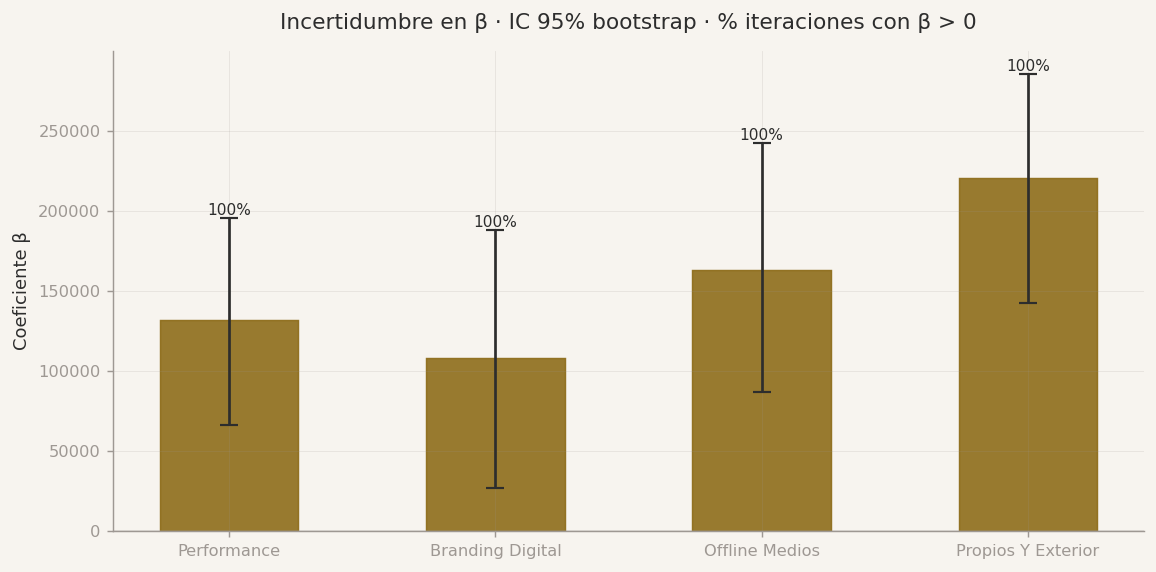

In [10]:
# ── Gráfica 4: bootstrap IC 95% por bloque ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

labels_ch = [c.replace("logadstock_", "").replace("_", " ").title() for c in LOGADSTOCK_COLS]
ch_idx    = [FEATURE_COLS.index(c) for c in LOGADSTOCK_COLS]
x = np.arange(len(labels_ch))

betas  = np.array([model.coef_[i] for i in ch_idx])
lo_arr = np.array([boot_lo[i]     for i in ch_idx])
hi_arr = np.array([boot_hi[i]     for i in ch_idx])
sig    = np.array([sign_stab[i]   for i in ch_idx])

colors = [KM_GOLD_DARK if l > 0 else KM_GRAY for l in lo_arr]
ax.bar(x, betas, color=colors, alpha=0.88, width=0.52,
       edgecolor=[KM_GOLD_DARK if l > 0 else KM_GRAY for l in lo_arr], lw=0.8)
ax.errorbar(x, betas,
            yerr=[betas - lo_arr, hi_arr - betas],
            fmt="none", color=KM_CHARCOAL, lw=1.5, capsize=5, capthick=1.2)

for i, (s, b, h) in enumerate(zip(sig, betas, hi_arr)):
    ax.text(i, h + 0.0004, f"{s:.0f}%",
            ha="center", va="bottom", fontsize=8.5, color=KM_CHARCOAL)

ax.set_xticks(x);  ax.set_xticklabels(labels_ch, fontsize=9)
ax.axhline(0, color=KM_GRAY, lw=0.8)
ax.set_ylabel("Coeficiente β")
ax.set_title("Incertidumbre en β · IC 95% bootstrap · % iteraciones con β > 0")

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "mod_g4_bootstrap.png"), dpi=150)
plt.show()

## 6. Test placebo — ¿el modelo identifica señal real?

Sustituimos las inversiones por ruido con la misma media, std y autocorrelación. 
Si el R² apenas baja → el modelo predice controles, no medios. 
Si baja mucho (ΔR² > 0.05) → hay señal real de marketing.

In [11]:
# Generar inversiones placebo (ruido con autocorrelación similar)
X_train_placebo = X_train.copy()
X_test_placebo  = X_test.copy()

for col in LOGADSTOCK_COLS:
    j = FEATURE_COLS.index(col)
    for X_p, seed_offset in [(X_train_placebo, 0), (X_test_placebo, 100)]:
        original = X_p[:, j]
        rng_p = np.random.default_rng(RANDOM_SEED + j + seed_offset)
        noise = rng_p.normal(original.mean(), original.std(), len(original))
        # Suavizar para autocorrelación ~0.7
        for t in range(1, len(noise)):
            noise[t] = 0.7 * noise[t-1] + 0.3 * noise[t]
        X_p[:, j] = noise

model_placebo = ElasticNet(alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO,
                           positive=True,
                           max_iter=10_000, random_state=RANDOM_SEED)
model_placebo.fit(X_train_placebo, y_train)

r2_placebo  = r2_score(y_test, model_placebo.predict(X_test_placebo))
mape_placebo = mape(y_test, model_placebo.predict(X_test_placebo))
delta_r2    = test_r2 - r2_placebo

print("═" * 55)
print("  TEST PLACEBO")
print("═" * 55)
print(f"  R² modelo real:    {test_r2:.4f}  MAPE={test_mape:.1f}%")
print(f"  R² modelo placebo: {r2_placebo:.4f}  MAPE={mape_placebo:.1f}%")
print(f"  ΔR²:               {delta_r2:+.4f}")
print()
if delta_r2 > 0.05:
    print("  ✓ El modelo identifica señal de medios por encima de los controles.")
elif delta_r2 > 0.01:
    print("  ⚠ Señal de medios marginal — interpretar con cautela.")
else:
    print("  ✗ El modelo NO identifica señal de medios significativa.")
print(f"\n  β placebo (marketing):")
for col in LOGADSTOCK_COLS:
    j = FEATURE_COLS.index(col)
    print(f"    {col.replace('logadstock_',''):<20s}  real={model.coef_[j]:.5f}  placebo={model_placebo.coef_[j]:.5f}")
print("═" * 55)

═══════════════════════════════════════════════════════
  TEST PLACEBO
═══════════════════════════════════════════════════════
  R² modelo real:    0.6487  MAPE=12.2%
  R² modelo placebo: 0.1138  MAPE=20.1%
  ΔR²:               +0.5350

  ✓ El modelo identifica señal de medios por encima de los controles.

  β placebo (marketing):
    performance           real=131964.62920  placebo=0.00000
    branding_digital      real=108010.60249  placebo=140335.79644
    offline_medios        real=162806.59538  placebo=0.00000
    propios_y_exterior    real=220570.12672  placebo=348427.10301
═══════════════════════════════════════════════════════


## 7. Descomposición de contribuciones

**Contrafactual:** la contribución de un bloque es la caída predicha si apagas ese bloque 
(logadstock = 0 raw → escalado a su valor cero). La base es el escenario con ambos bloques apagados.

In [12]:
X_all      = df[FEATURE_COLS].values


# Base = predicción con logadstock forzados a 0
X_base = X_all.copy()
for col in LOGADSTOCK_COLS:
    j       = FEATURE_COLS.index(col)
    j_scale = COLS_TO_SCALE.index(col)
    X_base[:, j] = (0.0 - scaler.mean_[j_scale]) / scaler.scale_[j_scale]

base_pred_eur  = model.predict(X_base)      # ya en €
total_pred_eur = model.predict(X_all)       # ya en €

# Contribución por bloque (contrafactual)
contribs_eur = {}
for col in LOGADSTOCK_COLS:
    j       = FEATURE_COLS.index(col)
    j_scale = COLS_TO_SCALE.index(col)
    X_off   = X_all.copy()
    X_off[:, j] = (0.0 - scaler.mean_[j_scale]) / scaler.scale_[j_scale]
    contribs_eur[col] = total_pred_eur - model.predict(X_off)   # diferencia en €

total_mkt_eur = sum(contribs_eur.values())
pct_mkt  = total_mkt_eur.sum() / total_pred_eur.sum() * 100
pct_base = 100 - pct_mkt

print(f"Base (sin marketing): {pct_base:.1f}%  (€{base_pred_eur.sum()/1e6:.1f}M)")
print(f"Marketing total:      {pct_mkt:.1f}%  (€{total_mkt_eur.sum()/1e6:.1f}M)")
print()
print(f"{'Bloque':<22s}  {'Contrib M€':>10}  {'% ventas':>9}  {'Inversión M€':>12}  {'ROI':>6}")
print("─" * 68)
for col in LOGADSTOCK_COLS:
    nombre        = col.replace("logadstock_", "")
    inv_total     = df[CHANNEL_GROUPS[nombre]].sum().sum() if nombre in CHANNEL_GROUPS else 0
    contrib_total = contribs_eur[col].sum()
    pct           = contrib_total / total_pred_eur.sum() * 100
    roi           = contrib_total / inv_total if inv_total > 0 else 0
    print(f"  {nombre:<20s}  {contrib_total/1e6:>9.2f}M  {pct:>8.1f}%  {inv_total/1e6:>11.2f}M  {roi:>5.2f}x")

Base (sin marketing): 8.2%  (€62.2M)
Marketing total:      91.8%  (€695.0M)

Bloque                  Contrib M€   % ventas  Inversión M€     ROI
────────────────────────────────────────────────────────────────────
  performance              141.81M      18.7%        23.48M   6.04x
  branding_digital         115.40M      15.2%        13.64M   8.46x
  offline_medios           181.03M      23.9%        11.84M  15.29x
  propios_y_exterior       256.74M      33.9%        10.00M  25.67x


### Gráfica 5 · Descomposición de ventas: base vs marketing

Área apilada que muestra qué fracción de cada semana se atribuye a la inversión en medios
frente a la base (demanda estructural). La línea punteada es la venta real.

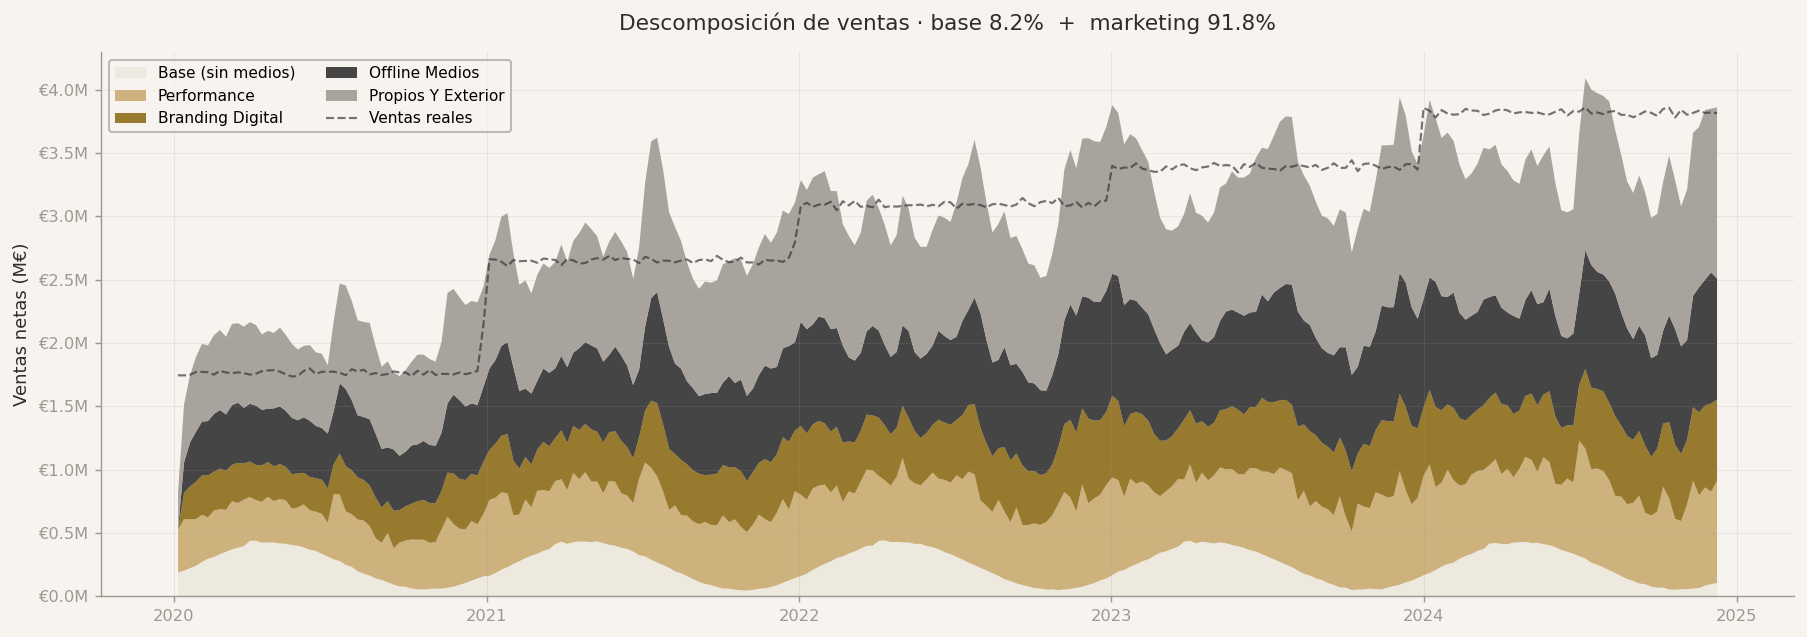

In [13]:
# ── Gráfica 5: descomposición ventas base + contribuciones ───────────────────
fig, ax = plt.subplots(figsize=(14, 5))

contrib_labels = [c.replace("logadstock_", "").replace("_", " ").title() for c in LOGADSTOCK_COLS]
stacked_data   = [base_pred_eur] + [contribs_eur[c] for c in LOGADSTOCK_COLS]
stacked_labels = ["Base (sin medios)"] + contrib_labels
stacked_colors = [KM_IVORY] + KM_CHANNELS[:len(LOGADSTOCK_COLS)]

ax.stackplot(dates_all, stacked_data,
             labels=stacked_labels, colors=stacked_colors, alpha=0.88)
ax.plot(dates_all, y_all_true, color=KM_CHARCOAL, lw=1.2, ls="--",
        alpha=0.65, label="Ventas reales")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title(f"Descomposición de ventas · base {pct_base:.1f}%  +  marketing {pct_mkt:.1f}%")
ax.set_ylabel("Ventas netas (M€)")
ax.legend(loc="upper left", ncol=2, fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "mod_g5_descomposicion.png"), dpi=150)
plt.show()

## 8. Función de simulación

In [14]:
def _adstock(series, alpha, lag=0):
    x = pd.Series(series).shift(lag).fillna(0).to_numpy(dtype=float)
    out = np.zeros_like(x)
    for t in range(len(x)):
        out[t] = x[t] + (alpha * out[t-1] if t > 0 else 0.0)
    return out

def _build_X_sim(inv_nueva: dict, n_semanas: int = 52) -> np.ndarray:
    """Construye X para un escenario de inversión (€/semana por grupo)."""
    logads_raw = np.zeros((n_semanas, len(LOGADSTOCK_COLS)))
    for group_col, p in best_params.items():
        logcol = f"logadstock_{group_col.replace('inv_', '')}"
        j = LOGADSTOCK_COLS.index(logcol)
        k = saturation_k[group_col]
        A = _adstock(np.ones(n_semanas) * inv_nueva.get(group_col, 0.0), p["alpha"], p["lag"])
        logads_raw[:, j] = np.log1p(A / k)
    
    rest_means = scaler.mean_[len(LOGADSTOCK_COLS):]
    to_scale = np.hstack([logads_raw, np.tile(rest_means, (n_semanas, 1))])
    scaled = scaler.transform(to_scale)
    
    X_sim = np.tile(df[FEATURE_COLS].mean().values, (n_semanas, 1))
    for i, col in enumerate(LOGADSTOCK_COLS):
        X_sim[:, FEATURE_COLS.index(col)] = scaled[:, i]
    return X_sim

def simular(inv_nueva: dict, n_semanas: int = 52) -> dict:
    """Si invierto X€/semana en cada grupo, ¿cuántas ventas anuales genero?"""
    X_sim        = _build_X_sim(inv_nueva, n_semanas)
    ventas_anual = model.predict(X_sim).sum()          # ya en € · suma 52 semanas

    inv_hist    = {g: df[g].mean() for g in INV_GROUP_COLS}
    ventas_hist = model.predict(_build_X_sim(inv_hist, n_semanas)).sum()
    lift_eur    = ventas_anual - ventas_hist
    inv_total   = sum(inv_nueva.values()) * n_semanas

    return {
        "ventas_anual_eur": ventas_anual,
        "lift_eur":         lift_eur,
        "lift_pct":         lift_eur / ventas_hist * 100 if ventas_hist else 0,
        "roi":              lift_eur / inv_total if inv_total > 0 else 0,
    }

def simular_ic(inv_nueva: dict, n_semanas: int = 52) -> dict:
    """Como simular(), añade IC 95% bootstrap."""
    X_sim     = _build_X_sim(inv_nueva, n_semanas)
    resultado = simular(inv_nueva, n_semanas)

    ventas_boot = [
        np.maximum(model.intercept_ + X_sim @ coefs, 0).sum()   # ya en €
        for coefs in boot_coefs
    ]
    resultado["ic_lo_eur"]  = np.percentile(ventas_boot, 2.5)
    resultado["ic_hi_eur"]  = np.percentile(ventas_boot, 97.5)
    resultado["riesgo_eur"] = resultado["ic_hi_eur"] - resultado["ic_lo_eur"]
    return resultado

# Ejemplo
inv_actual = {g: df[g].mean() for g in INV_GROUP_COLS}
inv_esc = {**inv_actual}
"""inv_esc["inv_digital"] *= 1.20
inv_esc["inv_tradicional"] *= 0.80"""

inv_esc["inv_performance"] *= 1.20
inv_esc["inv_branding_digital"] *= 1.20
inv_esc["inv_offline_medios"] *= 0.80
inv_esc["inv_propios_y_exterior"] *= 0.80

r = simular_ic(inv_esc)
print(f"Ventas estimadas : €{r['ventas_anual_eur']/1e6:.2f}M")
print(f"Lift vs histórico: €{r['lift_eur']/1e6:+.2f}M  ({r['lift_pct']:+.1f}%)")
print(f"IC 95%           : [€{r['ic_lo_eur']/1e6:.2f}M, €{r['ic_hi_eur']/1e6:.2f}M]")

Ventas estimadas : €145.51M
Lift vs histórico: €-6.19M  (-4.1%)
IC 95%           : [€139.09M, €152.02M]


## 9. Guardar modelo

In [15]:
# Reentrenar sobre todo el dataset para el optimizador
X_all = df[FEATURE_COLS].values
y_all = df[TARGET_IDX].values

model_full = ElasticNet(
    alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO,
    positive=True,
    max_iter=10_000, random_state=RANDOM_SEED,
)
model_full.fit(X_all, y_all)

with open(os.path.join(WAREHOUSE, "elastic_net.pkl"), "wb") as f:
    pickle.dump({
        "model":           model_full,
        "feature_cols":    FEATURE_COLS,
        "logadstock_cols": LOGADSTOCK_COLS,
        "target_idx":      TARGET_IDX,
        "best_alpha":      BEST_ALPHA,
        "best_l1_ratio":   BEST_L1_RATIO,
        "boot_coefs":      boot_coefs,
        "boot_lo":         boot_lo,
        "boot_hi":         boot_hi,
        "contribs_eur":    contribs_eur,
        "pct_mkt_total":   pct_mkt,
        "metrics": {
            "train_r2": train_r2, "test_r2": test_r2,
            "train_mape": train_mape, "test_mape": test_mape,
            "r2_placebo": r2_placebo, "delta_r2_placebo": delta_r2,
        },
    }, f)

print("✓ elastic_net.pkl guardado")
print(f"  Train R²={train_r2:.3f}  Test R²={test_r2:.3f}  Test MAPE={test_mape:.1f}%")
print(f"  ΔR² placebo: {delta_r2:+.4f}")
print(f"  % marketing: {pct_mkt:.1f}%")
print(f"  Bloques activos (β>0): {n_mkt_active}/{len(LOGADSTOCK_COLS)}")

✓ elastic_net.pkl guardado
  Train R²=0.773  Test R²=0.649  Test MAPE=12.2%
  ΔR² placebo: +0.5350
  % marketing: 91.8%
  Bloques activos (β>0): 4/4
